In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [22]:
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

In [23]:
df.shape

(19402, 4)

In [24]:
japon = df[df['entity'] == "Japan"]
japon.head()
mexico = df[df['entity'] == "Mexico"]
mexico.head()

,entity,code,year,fertility_rate_hist
11125,Mexico,MEX,1950,6.709
11126,Mexico,MEX,1951,6.727
11127,Mexico,MEX,1952,6.731
11128,Mexico,MEX,1953,6.734
11129,Mexico,MEX,1954,6.745


In [25]:
anios_japon = japon["year"].to_numpy()
tasa_japon = japon["fertility_rate_hist"].to_numpy()
type(anios_japon)

anios_mexico = mexico["year"].to_numpy()
tasa_mexico = mexico["fertility_rate_hist"].to_numpy()
type(anios_mexico)

numpy.ndarray

In [26]:
promedio_mexico = np.mean(tasa_mexico)
maximo_mexico = np.max(tasa_mexico)
minimo_mexico = np.min(tasa_mexico)
std_mexico = np.std(tasa_mexico)

promedio_japon = np.mean(tasa_japon)
maximo_japon = np.max(tasa_japon)
minimo_japon = np.min(tasa_japon)
std_japon = np.std(tasa_japon)

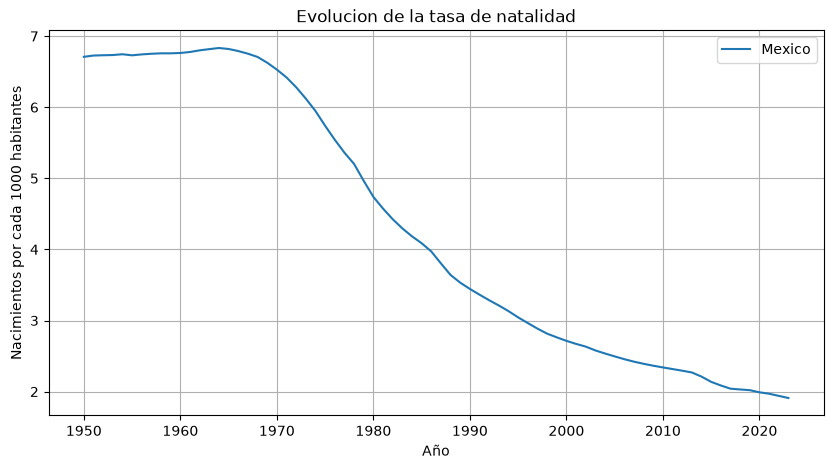

In [27]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_mexico,
    tasa_mexico,
    label="Mexico"
)
plt.title("Evolucion de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1000 habitantes")
plt.grid(True)
plt.legend()

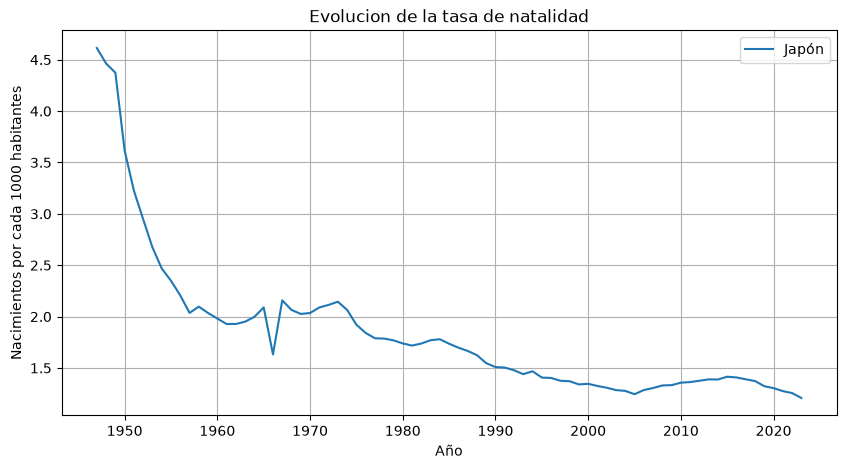

In [28]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_japon,
    tasa_japon,
    label="Japón"
)
plt.title("Evolucion de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1000 habitantes")
plt.grid(True)
plt.legend()

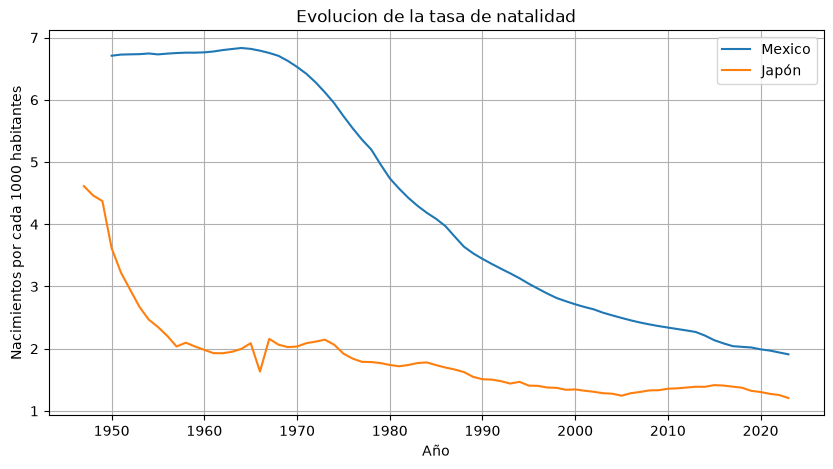

In [29]:
plt.figure(figsize=(10,5))
plt.plot(anios_mexico, tasa_mexico, label="Mexico")
plt.plot(anios_japon, tasa_japon, label="Japón")
plt.title("Evolucion de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1000 habitantes")
plt.grid(True)
plt.legend()

In [30]:
mascara_coincidiencia = anios_japon >= anios_mexico.min()


In [31]:
anios_japon = anios_japon[mascara_coincidiencia]

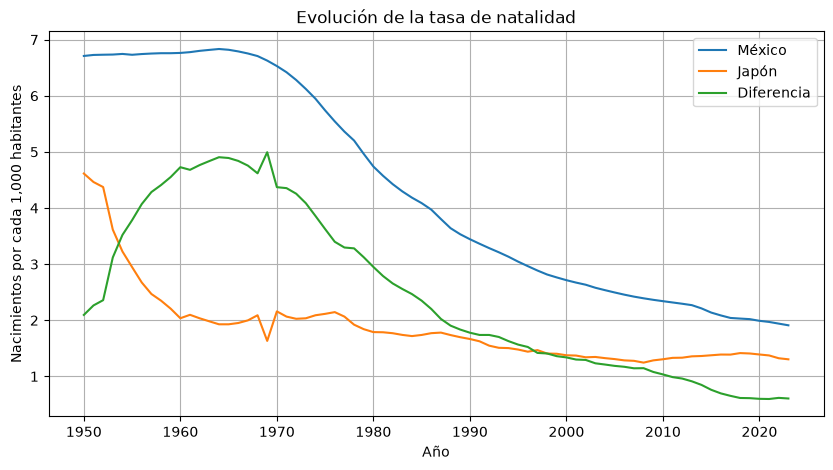

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Aseguramos orden ascendente (necesario para searchsorted)
orden_mexico = np.argsort(anios_mexico)
anios_mexico = anios_mexico[orden_mexico]
tasa_mexico = tasa_mexico[orden_mexico]

orden_japon = np.argsort(anios_japon)
anios_japon = anios_japon[orden_japon]
tasa_japon = tasa_japon[orden_japon]

# Años comunes, ya ordenados
anios_comunes = np.intersect1d(anios_mexico, anios_japon)

# Índices exactos de cada año común en cada array original
idx_mexico = np.searchsorted(anios_mexico, anios_comunes)
idx_japon = np.searchsorted(anios_japon, anios_comunes)

tasa_mexico_comun = tasa_mexico[idx_mexico]
tasa_japon_comun = tasa_japon[idx_japon]

diferencia_mx_jp = tasa_mexico_comun - tasa_japon_comun

plt.figure(figsize=(10, 5))

plt.plot(anios_comunes, tasa_mexico_comun, label="México")
plt.plot(anios_comunes, tasa_japon_comun, label="Japón")
plt.plot(anios_comunes, diferencia_mx_jp, label="Diferencia")

plt.title("Evolución de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

plt.show()

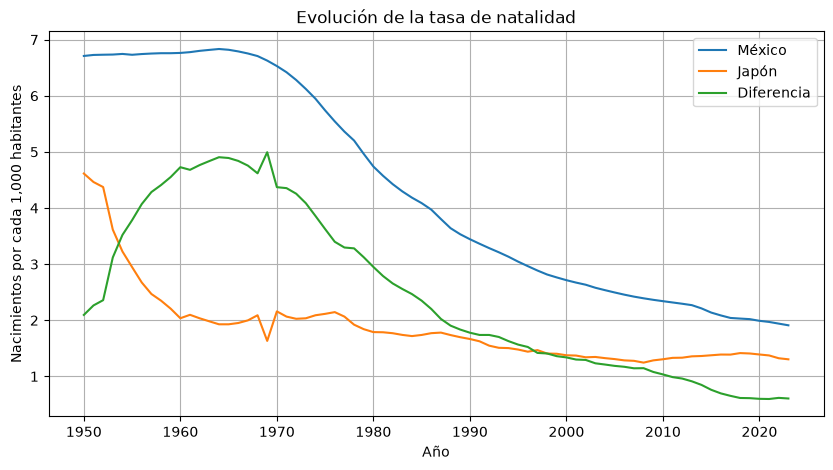

In [33]:
plt.figure(figsize=(10,5))

plt.plot(
    anios_mexico,
    tasa_mexico,
    label = "México"
)

plt.plot(
    anios_japon,
    tasa_japon,
    label = "Japón"
)

plt.plot(
    anios_mexico,
    diferencia_mx_jp,
    label = "Diferencia"
)


plt.title("Evolución de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [34]:
anios_comunes = np.intersect1d(anios_mexico, anios_japon)

In [35]:
comparacion_mexico_japon = pd.merge(
    mexico[["year", "fertility_rate_hist"]],
    japon[["year", "fertility_rate_hist"]],
    on="year",
    suffixes=("_mexico", "_japon")
)

In [36]:
comparacion_mexico_japon.head(3)

,year,fertility_rate_hist_mexico,fertility_rate_hist_japon
0,1950,6.709,3.615
1,1951,6.727,3.225
2,1952,6.731,2.947


In [47]:
anios_japon = np.delete(anios_japon, [23,25,30,42,48])

In [48]:
anios_comunes = np.intersect1d(
    anios_mexico,
    anios_japon
)

In [49]:
mexico_anios_comunes = mexico[mexico["year"].isin(anios_comunes)]
japon_anios_comunes = japon[japon["year"].isin(anios_comunes)]


In [50]:
anios_comunes.shape

(69,)

In [51]:
print(anios_comunes)

[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963
 1964 1965 1966 1967 1968 1969 1970 1971 1972 1974 1976 1977 1978 1979
 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1993 1994 1995
 1996 1997 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010
 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023]


In [ ]:
mex_anios_comunes = mexico_anios_comunes["year"].to_numpy()
jpn_anios_comunes = japon_anios_comunes["year"].to_numpy()

mex_tasa_comunes = mexico_anios_comunes["fertility_rate_hist"].to_numpy()
jpn_tasa_comunes = japon_anios_comunes["fertility_rate_hist"].to_numpy()

: 